# EDA — Movie Discovery Assistant

Exploratory analysis of the MovieLens-filtered dataset. This notebook is the
evidence base for the design decisions in the code (thresholds, cohort
definitions, which signals to trust) and for the Problem Analysis / Approach
sections of `REPORT.md`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 4)

DATA_DIR = "../data/ml-latest-small-filtered"

movies = pd.read_csv(f"{DATA_DIR}/movies_with_plots.csv")
ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")
tags = pd.read_csv(f"{DATA_DIR}/tags.csv")
links = pd.read_csv(f"{DATA_DIR}/links.csv")
movies_basic = pd.read_csv(f"{DATA_DIR}/movies.csv")


## 1. Data overview

Shape, dtypes, missing values, duplicates per file.

In [2]:
for name, df in [("movies_with_plots", movies), ("ratings", ratings),
                  ("tags", tags), ("links", links), ("movies", movies_basic)]:
    print(f"--- {name} ---")
    print("shape:", df.shape)
    print("dtypes:\n", df.dtypes)
    print("missing:\n", df.isna().sum())
    print("duplicate rows:", df.duplicated().sum())
    print()


--- movies_with_plots ---
shape: (5135, 5)
dtypes:
 movieId    int64
title        str
year       int64
genres       str
plot         str
dtype: object
missing:
 movieId    0
title      0
year       0
genres     0
plot       0
dtype: int64
duplicate rows: 0

--- ratings ---
shape: (74064, 4)
dtypes:
 userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object
missing:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
duplicate rows: 0

--- tags ---
shape: (2440, 4)
dtypes:
 userId       int64
movieId      int64
tag            str
timestamp    int64
dtype: object
missing:
 userId       0
movieId      0
tag          0
timestamp    0
dtype: int64
duplicate rows: 0

--- links ---
shape: (5135, 3)
dtypes:
 movieId      int64
imdbId       int64
tmdbId     float64
dtype: object
missing:
 movieId    0
imdbId     0
tmdbId     3
dtype: int64
duplicate rows: 0

--- movies ---
shape: (5135, 3)
dtypes:
 movieId    int64
title        str
g

## 1b. Data quality check: duplicate/mismatched plot text

Sanity-check whether every movie actually has a *distinct, correct* plot —
this directly affects how much we can trust content-based (embedding)
search.

In [3]:
dup_counts = movies.groupby("plot")["movieId"].nunique()
duplicated_plots = dup_counts[dup_counts > 1]
affected_movies = int(duplicated_plots.sum())
print(f"Distinct plot texts shared by >1 movie: {len(duplicated_plots)}")
print(f"Movies affected: {affected_movies} ({affected_movies / len(movies):.1%} of the catalog)")

# Show one concrete example: same plot text attached to unrelated titles
example_plot = duplicated_plots.index[0]
example_titles = movies.loc[movies["plot"] == example_plot, ["movieId", "title"]]
print("\nExample: identical plot text incorrectly shared by:")
print(example_titles.to_string(index=False))


Distinct plot texts shared by >1 movie: 41
Movies affected: 198 (3.9% of the catalog)

Example: identical plot text incorrectly shared by:
 movieId          title
    1018 That Darn Cat!
    1460  That Darn Cat


In [4]:
import re

# Does this data bug actually surface in a live recommendation, or is it only
# a theoretical 3.9%? Cross-check the duplicate-plot movie ids against titles
# that appear in the real agent transcripts in results/sample_conversations.md.
dup_movie_ids = set(movies.loc[movies["plot"].isin(duplicated_plots.index), "movieId"])
transcript = open("../results/sample_conversations.md").read()

hits = [
    (mid, title)
    for mid, title in movies.loc[movies["movieId"].isin(dup_movie_ids), ["movieId", "title"]].itertuples(index=False)
    if re.search(re.escape(title), transcript)
]
print(f"Duplicate-plot movies that were actually recommended in a transcript: {hits}")

if hits:
    mid = hits[0][0]
    partner_plot = movies.loc[movies["movieId"] == mid, "plot"].values[0]
    partners = movies.loc[movies["plot"] == partner_plot, ["movieId", "title"]]
    print(f"\n'{hits[0][1]}' (movieId={mid}) shares its stored plot with:")
    print(partners.to_string(index=False))
    print(f"\nShared plot text (first 300 chars):\n{partner_plot[:300]}")


Duplicate-plot movies that were actually recommended in a transcript: [(1172, 'Cinema Paradiso (Nuovo cinema Paradiso)')]

'Cinema Paradiso (Nuovo cinema Paradiso)' (movieId=1172) shares its stored plot with:
 movieId                                   title
    1172 Cinema Paradiso (Nuovo cinema Paradiso)
    1185                            My Left Foot

Shared plot text (first 300 chars):
The story begins with Hannah, a young Jewish teen, as she is completing her senior year of high school. Her small neighborhood in Brooklyn is falling apart and SING! is one of the only traditions keeping the neighborhood alive. Newly arrived teacher, Miss Lombardo grew up in the neighborhood but ret


**Confirmed, concrete instance:** *Cinema Paradiso (Nuovo cinema Paradiso)* (movieId 1172) was recommended to user 30 twice in `results/sample_conversations.md` (the "what should I watch tonight?" and "tired of animated movies" queries), described by the assistant as *"a touching story of friendship and nostalgia."* Its stored plot text, however, is identical to movieId 1185 (*My Left Foot*) and is actually neither film's real plot — it describes an unrelated story about a Brooklyn Jewish teen and a school "SING!" tradition. So this specific recommendation's description came from the LLM's own background knowledge of the real "Cinema Paradiso," not from the (corrupted) tool data — which is itself a second, more subtle failure mode worth naming: the grounding instruction in `agent/prompt.py` didn't stop the model from filling a data gap with prior knowledge here.

## 2. Rating distribution

Distribution of rating values, ratings per user, ratings per movie — this is the basis for the user-item sparsity claim and for the CF design.

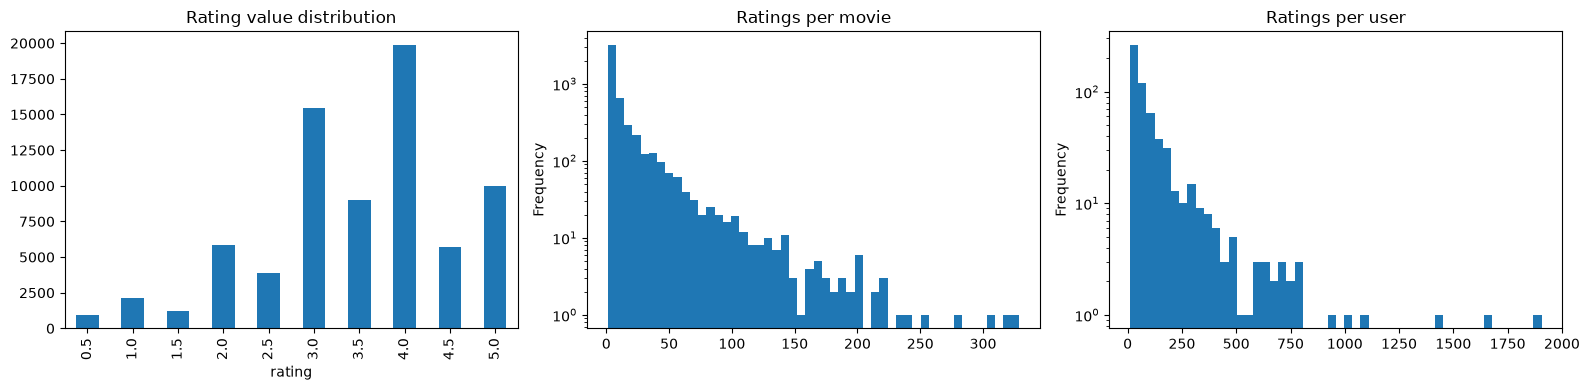

Users: 610, movies rated: 5126/5135
User-item matrix sparsity: 97.6355%
count    5126.000000
mean       14.448693
std        27.254429
min         1.000000
25%         2.000000
50%         4.000000
75%        14.000000
max       329.000000
dtype: float64
count     610.000000
mean      121.416393
std       186.574788
min        10.000000
25%        28.000000
50%        56.000000
75%       129.000000
max      1907.000000
dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Rating value distribution")

ratings_per_movie = ratings.groupby("movieId").size()
ratings_per_movie.plot(kind="hist", bins=50, ax=axes[1], title="Ratings per movie", logy=True)

ratings_per_user = ratings.groupby("userId").size()
ratings_per_user.plot(kind="hist", bins=50, ax=axes[2], title="Ratings per user", logy=True)

plt.tight_layout()
plt.show()

n_users = ratings["userId"].nunique()
n_movies_rated = ratings["movieId"].nunique()
n_movies_total = len(movies)
sparsity = 1 - len(ratings) / (n_users * n_movies_total)
print(f"Users: {n_users}, movies rated: {n_movies_rated}/{n_movies_total}")
print(f"User-item matrix sparsity: {sparsity:.4%}")
print(ratings_per_movie.describe())
print(ratings_per_user.describe())


## 3. Temporal

Timestamp range and whether rating volume drifts over time — informs the time-based train/test split for evaluation.

Rating date range: 1996-03-29 18:36:55 to 2018-09-24 14:27:30


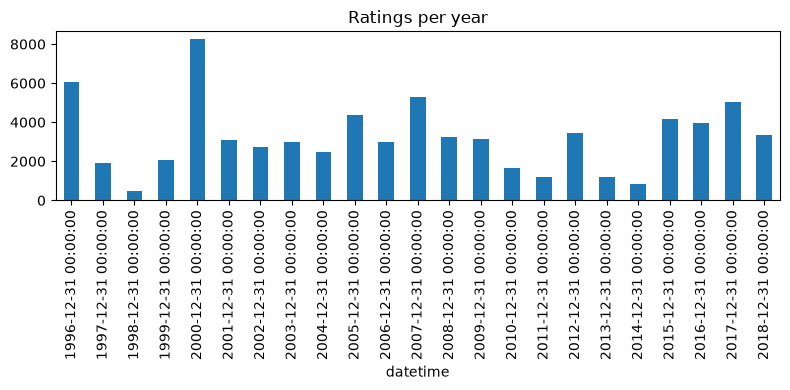

In [6]:
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
print("Rating date range:", ratings["datetime"].min(), "to", ratings["datetime"].max())

ratings.set_index("datetime").resample("YE").size().plot(kind="bar", title="Ratings per year")
plt.tight_layout()
plt.show()


## 4. Movie metadata

Release year distribution, genre distribution (single + co-occurrence), plot length distribution.

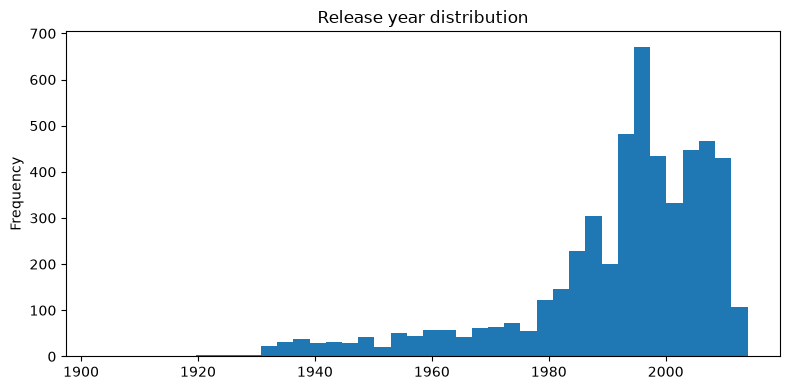

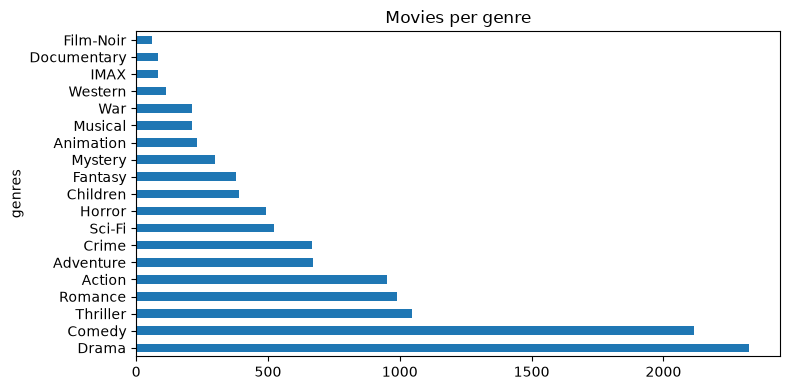

genres
Drama          2326
Comedy         2117
Thriller       1047
Romance         990
Action          953
Adventure       671
Crime           667
Sci-Fi          524
Horror          492
Children        390
Fantasy         379
Mystery         298
Animation       231
Musical         213
War             211
Western         113
IMAX             84
Documentary      82
Film-Noir        60
Name: count, dtype: int64


In [7]:
movies["year"].plot(kind="hist", bins=40, title="Release year distribution")
plt.tight_layout()
plt.show()

genre_lists = movies["genres"].fillna("").str.split("|")
all_genres = genre_lists.explode()
all_genres = all_genres[all_genres != "(no genres listed)"]
genre_counts = all_genres.value_counts()
genre_counts.plot(kind="barh", title="Movies per genre")
plt.tight_layout()
plt.show()
print(genre_counts)


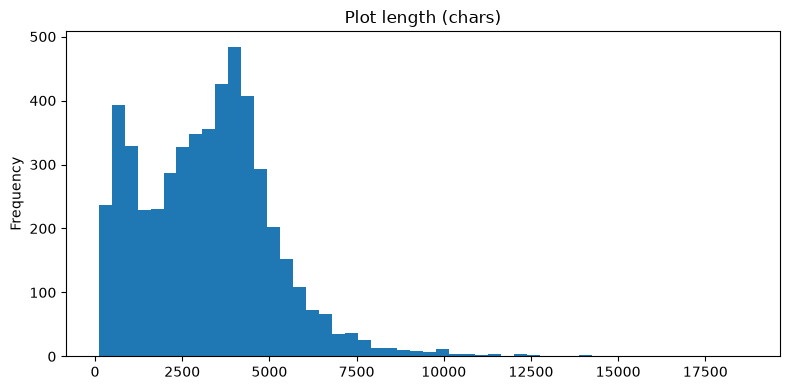

count     5135.000000
mean      3247.806232
std       1934.340790
min        103.000000
25%       1756.500000
50%       3281.000000
75%       4388.000000
max      18711.000000
Name: plot, dtype: float64


In [8]:
plot_lengths = movies["plot"].dropna().str.len()
plot_lengths.plot(kind="hist", bins=50, title="Plot length (chars)")
plt.tight_layout()
plt.show()
print(plot_lengths.describe())


## 5. Tag coverage

How sparse are tags, and do they add signal beyond genres? Confirms the README's note that tags shouldn't be a primary signal.

In [9]:
tags_per_movie = tags.groupby("movieId").size()
print(f"Movies with at least one tag: {tags['movieId'].nunique()}/{len(movies)}")
print(tags_per_movie.describe())
print()
print("Most common tags:")
print(tags["tag"].str.lower().value_counts().head(20))


Movies with at least one tag: 1026/5135
count    1026.000000
mean        2.378168
std         6.618766
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       181.000000
dtype: float64

Most common tags:
tag
in netflix queue     71
atmospheric          24
disney               19
thought-provoking    19
dark comedy          18
sci-fi               18
twist ending         16
time travel          16
psychology           16
surreal              15
music                15
high school          15
politics             15
superhero            14
mental illness       14
religion             14
quirky               13
space                13
suspense             13
aliens               13
Name: count, dtype: int64


## 6. User profile

Per-user average rating and rating count — needed to define 'dense' vs 'sparse' user cohorts for evaluation.

         n_ratings  avg_rating  rating_std
count   610.000000  610.000000  610.000000
mean    121.416393    3.653279    0.917156
std     186.574788    0.490989    0.273963
min      10.000000    1.315789    0.000000
25%      28.000000    3.358766    0.720285
50%      56.000000    3.683588    0.900111
75%     129.000000    3.989702    1.078834
max    1907.000000    5.000000    2.028464


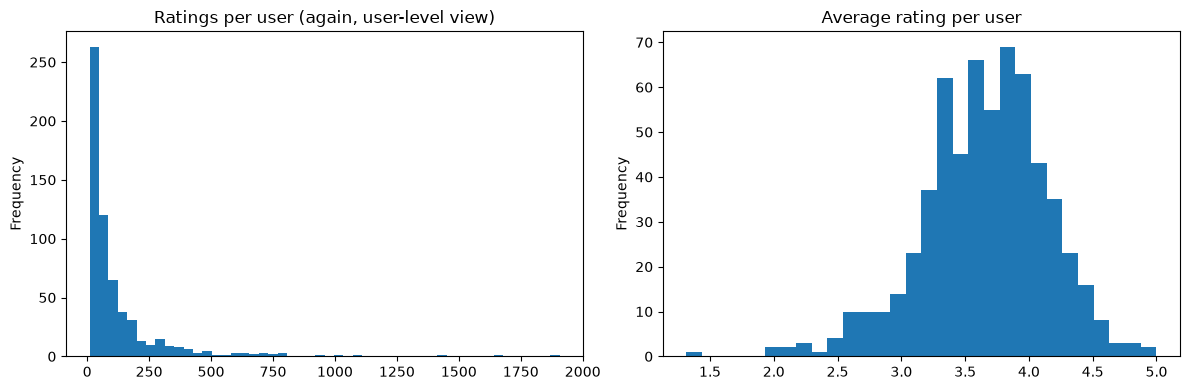

n_ratings quantile 0.1: 19.0
n_ratings quantile 0.25: 28.0
n_ratings quantile 0.5: 56.0
n_ratings quantile 0.75: 129.0
n_ratings quantile 0.9: 292.3


In [10]:
user_stats = ratings.groupby("userId")["rating"].agg(["count", "mean", "std"]).rename(
    columns={"count": "n_ratings", "mean": "avg_rating", "std": "rating_std"}
)
print(user_stats.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
user_stats["n_ratings"].plot(kind="hist", bins=50, ax=axes[0], title="Ratings per user (again, user-level view)")
user_stats["avg_rating"].plot(kind="hist", bins=30, ax=axes[1], title="Average rating per user")
plt.tight_layout()
plt.show()

for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
    print(f"n_ratings quantile {q}: {user_stats['n_ratings'].quantile(q):.1f}")


## 7. Cold-start check

% of movies with very few ratings, % of users with few ratings — quantifies the cold-start problem the recommender must handle.

In [11]:
pct_movies_lt5 = (ratings_per_movie < 5).mean()
pct_users_lt20 = (user_stats["n_ratings"] < 20).mean()
pct_users_ge100 = (user_stats["n_ratings"] >= 100).mean()
print(f"Movies with <5 ratings: {pct_movies_lt5:.1%} (of rated movies)")
print(f"Movies with <5 ratings (of ALL movies incl. unrated): {(len(movies) - (ratings_per_movie >= 5).sum()) / len(movies):.1%}")
print(f"Users with <20 ratings: {pct_users_lt20:.1%}")
print(f"Users with >=100 ratings: {pct_users_ge100:.1%}")


Movies with <5 ratings: 51.1% (of rated movies)
Movies with <5 ratings (of ALL movies incl. unrated): 51.2%
Users with <20 ratings: 12.6%
Users with >=100 ratings: 32.6%


## 8. Deep dive on 3 suggested test users (userId 1, 15, 30)

Genre profile and top-rated movies for the users named in the README, used later to sanity-check the live agent demo.

In [12]:
def user_profile(uid: int, top_n: int = 8) -> None:
    user_ratings = ratings[ratings["userId"] == uid].merge(movies, on="movieId")
    print(f"--- userId={uid} ---")
    print(f"n_ratings={len(user_ratings)}, avg_rating={user_ratings['rating'].mean():.2f}")
    genre_counts = user_ratings["genres"].str.split("|").explode().value_counts()
    print("Top genres:\n", genre_counts.head(5))
    top_movies = user_ratings.sort_values("rating", ascending=False).head(top_n)
    print("Top rated movies:\n", top_movies[["title", "rating", "genres"]].to_string(index=False))
    print()

for uid in [1, 15, 30]:
    user_profile(uid)


--- userId=1 ---
n_ratings=190, avg_rating=4.33
Top genres:
 genres
Action       74
Adventure    68
Comedy       68
Drama        54
Thriller     47
Name: count, dtype: int64
Top rated movies:
                               title  rating                          genres
Willy Wonka & the Chocolate Factory     5.0 Children|Comedy|Fantasy|Musical
                    Terminator, The     5.0          Action|Sci-Fi|Thriller
                            Henry V     5.0        Action|Drama|Romance|War
                  Full Metal Jacket     5.0                       Drama|War
                Blues Brothers, The     5.0           Action|Comedy|Musical
                    American Beauty     5.0                   Drama|Romance
                          Excalibur     5.0               Adventure|Fantasy
                         Goodfellas     5.0                     Crime|Drama

--- userId=15 ---
n_ratings=85, avg_rating=3.55
Top genres:
 genres
Sci-Fi       38
Action       35
Drama        35
Advent

## 9. Insights & design implications

- **User-item sparsity is high, but rating density is concentrated on the user side.** Users average ~121 ratings while ~51% of movies have <5 ratings.
  -> User-based collaborative filtering (finding similar *users*) is more reliable than item-based CF here, and pure CF will fail for long-tail movies -> the recommender needs a content-based/popularity fallback for cold-start items (`HybridRecommender`).
- **Ratings are skewed toward positive values** (most mass at 3.0-4.0+). A rating >= 4.0 is a reasonable, data-grounded threshold for "liked" in evaluation, rather than an arbitrary pick.
- **Tags are extremely sparse** relative to movies (a small fraction of movies have any tag, and most of those have very few). Confirms the README's warning: tags are used only as a supplementary, high-signal-when-present feature, never as the primary retrieval signal.
- **Plot length is long and highly variable** (avg ~3,200 chars) -> good raw material for sentence embeddings (BGE) but means truncation/quality checks matter when encoding; a short user query embedded with the same model still works because BGE is trained for asymmetric query/passage retrieval.
- **Rating volume is not uniform over time** -> a time-based holdout (last ~20% of each user's ratings by timestamp) is more realistic for evaluation than a random split, since it mimics the actual "predict what they'll rate next" scenario.
- **User rating counts are bimodal enough** to justify a simple cohort split for evaluation: sparse users (<20 ratings, includes userId 30 from the README) vs dense users (>=100 ratings, includes userId 1). This directly drives the cohort breakdown in `evaluation/run_eval.py` and the Failure Analysis section of the report.

- **A small but real slice of the catalog has mismatched plot text** (~4% of movies share an identical, unrelated plot with at least one other title — likely a scraping/join error upstream in this filtered dataset). This is a content-based-search failure mode worth calling out explicitly: a handful of `search_movies_by_plot` results can be wrong not because the embedding model failed, but because the *source text* is wrong. Nothing to fix on our end (no ground-truth plot to recover), but it belongs in the Failure Analysis section of the report.
- **This isn't just theoretical — it happened in the recorded transcripts** (see the cross-check above): *Cinema Paradiso* was recommended to user 30 with a description that matches the real film, not the corrupted plot text actually stored for it. That means the failure mode is two-layered: (1) the source data is sometimes wrong, and (2) the LLM can silently paper over that with its own prior knowledge of a well-known title instead of surfacing the mismatch — which is exactly the kind of "answering from LLM knowledge, not grounded data" the system prompt is supposed to prevent, and evidently doesn't catch every time. Worth a one-line callout in the Reflection/Failure Analysis section as a concrete, named example rather than only the aggregate 3.9% stat.
</cell id="19b1ec98">